# geopandas I: datos vectoriales

[![Abrir en Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gf0657-programacionsig/2026-ii/blob/main/contenidos/iv-procesamiento-datos-geoespaciales/17-geopandas-datos-vectoriales.ipynb)

## Trabajo previo

### Lecturas

Antes de la clase, revise las siguientes lecturas, en inglés. La introducción de la documentación oficial presenta las estructuras de datos de geopandas y sus operaciones básicas; la lección de Kaggle construye un primer mapa y es breve e interactiva.

GeoPandas developers. (s. f.-a). Introduction to GeoPandas. En *GeoPandas documentation*. Recuperado el 4 de octubre de 2026, de https://geopandas.org/en/stable/getting_started/introduction.html
\
\
Kaggle. (s. f.). Your first map. En *Geospatial analysis*. Kaggle Learn. Recuperado el 4 de octubre de 2026, de https://www.kaggle.com/code/alexisbcook/your-first-map

### Otros recursos

La [guía del usuario de geopandas](https://geopandas.org/en/stable/docs/user_guide.html) es la referencia permanente de esta sección: en particular, las páginas sobre [estructuras de datos](https://geopandas.org/en/stable/docs/user_guide/data_structures.html), [lectura y escritura de archivos](https://geopandas.org/en/stable/docs/user_guide/io.html), [mapas](https://geopandas.org/en/stable/docs/user_guide/mapping.html), [mapas interactivos](https://geopandas.org/en/stable/docs/user_guide/interactive_mapping.html) y [sistemas de referencia de coordenadas](https://geopandas.org/en/stable/docs/user_guide/projections.html). El curso [Geospatial analysis](https://www.kaggle.com/learn/geospatial-analysis) de Kaggle cubre con ejercicios los temas de esta y la siguiente semana.

## Introducción

Este cuaderno abre la serie *geopandas*, que pone en práctica los conceptos de la lección [Datos geoespaciales](https://gf0657-programacionsig.github.io/2026-ii/datos-geoespaciales/): geometrías vectoriales, sistemas de referencia de coordenadas (SRC) y formatos de archivo. En las secciones anteriores los datos fueron tablas: una fila por cantón, con su población y su densidad. Lo que faltaba era el mapa, y con él las preguntas que solo se responden con la ubicación: ¿dónde?, ¿qué tan grande?, ¿qué está cerca de qué?

[geopandas](https://geopandas.org/) extiende pandas con un tipo de columna nuevo, la **geometría**, y con las operaciones que esa columna hace posibles: dibujar mapas, reproyectar, medir y, en la parte II, relacionar capas por su posición. Sus dos estructuras son la **GeoSeries**, una columna de geometrías (puntos, líneas o polígonos de shapely), y el **GeoDataFrame**, un DataFrame con una GeoSeries como **columna de geometría activa** (figura 1). Todo lo aprendido de pandas aplica sin cambios: `head()`, el filtrado booleano, `sort_values()`, `groupby()`, `merge()`. Para leer y escribir archivos, geopandas se apoya en [pyogrio](https://pyogrio.readthedocs.io/) y GDAL; para las geometrías, en [shapely](https://shapely.readthedocs.io/); para los SRC, en [pyproj](https://pyproj4.github.io/pyproj/); para los mapas, en matplotlib y en [folium](https://python-visualization.github.io/folium/).

<figure style="text-align: center;">
  <img
    src="https://raw.githubusercontent.com/gf0657-programacionsig/2026-ii/main/contenidos/iv-procesamiento-datos-geoespaciales/img/geodataframe.png"
    alt="Esquema de un GeoDataFrame"
    width="600"
  >
  <figcaption><strong>Figura 1</strong>. Un GeoDataFrame es un DataFrame con una columna de geometrías (GeoSeries). Fuente: GeoPandas developers (s. f.-a).</figcaption>
</figure>

Los datos de esta sección cambian de escala: en lugar de los cantones de Costa Rica, se usan los **países del mundo** de [Natural Earth](https://www.naturalearthdata.com/), un conjunto de datos cartográficos de dominio público con capas de países, ciudades, aeropuertos, ríos y lagos a varias escalas, y los **indicadores del desarrollo mundial** del [Banco Mundial](https://datos.bancomundial.org/), con una fila por país y año. Ambos están preparados para el curso en los directorios [`datos/natural-earth/`](https://github.com/gf0657-programacionsig/2026-ii/tree/main/datos/natural-earth) y [`datos/banco-mundial/`](https://github.com/gf0657-programacionsig/2026-ii/tree/main/datos/banco-mundial) del repositorio, cada uno con un LEEME que describe sus archivos y variables. La escala mundial tiene una ventaja didáctica: con datos de todo el planeta, las consecuencias de elegir un sistema de referencia de coordenadas u otro se ven a simple vista en el mapa (un país que parece el doble de grande, un mapa estirado), mientras que a la escala de Costa Rica solo se notan al medir.

Como todos los cuadernos del curso, puede ejecutarse en la nube, con la insignia "Abrir en Google Colab", o localmente, en [Visual Studio Code](https://gf0657-programacionsig.github.io/2026-ii/vscode/) con el ambiente `geopython` como kernel. Colab trae geopandas y folium instalados; la biblioteca [mapclassify](https://pysal.org/mapclassify/), que se usa en una subsección sobre clasificación, está en `geopython` pero no en Colab, donde se instala con `!pip install mapclassify` cuando haga falta. El archivo `.ipynb` puede descargarse con el botón de descarga (ícono de flecha hacia abajo) en la parte superior de la página del cuaderno, en el sitio web del curso.

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm

# Direcciones de los directorios de datos en el repositorio del curso
DATOS_NE = "https://raw.githubusercontent.com/gf0657-programacionsig/2026-ii/main/datos/natural-earth"
DATOS_BM = "https://raw.githubusercontent.com/gf0657-programacionsig/2026-ii/main/datos/banco-mundial"

# Colores de los cuadernos anteriores
AZUL = "#1F77B4"
NARANJA = "#D97B1B"

print("geopandas", gpd.__version__)

geopandas 1.1.4


## Carga de una capa

`gpd.read_file()` lee cualquier formato vectorial que GDAL conozca (GeoPackage, Shapefile, GeoJSON y [muchos más](https://gdal.org/en/stable/drivers/vector/)) desde una ruta local o desde una URL, y retorna un GeoDataFrame. Por convención, geopandas se importa como `gpd`. La capa de países de Natural Earth a escala 1:110 millones:

In [2]:
# Capa de países de Natural Earth (escala 1:110 M), en formato GeoPackage
paises = gpd.read_file(DATOS_NE + "/paises.gpkg")

paises.head()

,codigo,iso3,nombre,nombre_en,continente,subregion,poblacion_estimada,pib_millones,grupo_ingreso,geometry
0,FJI,FJI,Fiyi,Fiji,Oceanía,Melanesia,889953,5496,4. Ingreso mediano bajo,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,TZA,TZA,Tanzania,Tanzania,África,África oriental,58005463,63177,5. Ingreso bajo,"MULTIPOLYGON (((33.90371 -0.95, 34.07262 -1.05..."
2,SAH,ESH,Sahara Occidental,W. Sahara,África,África septentrional,603253,907,5. Ingreso bajo,"MULTIPOLYGON (((-8.66559 27.65643, -8.66512 27..."
3,CAN,CAN,Canadá,Canada,América del Norte,América septentrional,37589262,1736425,1. Ingreso alto: OCDE,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,USA,USA,Estados Unidos,United States of America,América del Norte,América septentrional,328239523,21433226,1. Ingreso alto: OCDE,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


Se ve como un DataFrame, y lo es, con una columna más: `geometry`, que contiene un polígono o multipolígono por país, impreso en WKT. Tres propiedades que no existen en pandas describen la parte geoespacial:

In [3]:
# Tipo del objeto, SRC y tipos de geometría
print(type(paises))
print(paises.shape)
print(paises.crs)
print(paises.geom_type.value_counts())

<class 'geopandas.geodataframe.GeoDataFrame'>
(177, 10)
EPSG:4326
MultiPolygon    177
Name: count, dtype: int64


- `crs` es el **sistema de referencia de coordenadas** de la capa: WGS84, el SRC geográfico en que se distribuyen casi todos los datos globales, con coordenadas en grados.
- `geom_type` es una Series con el tipo de geometría de cada fila. Aquí todas son multipolígonos, aunque la mayoría de los países tiene un solo cuerpo: la capa se guardó con el tipo "multi" para toda ella, lo que permite representar los países con islas o partes separadas.
- `geometry` es la columna de geometría activa, una GeoSeries. Una geometría individual es un objeto de shapely, que Jupyter dibuja:

MultiPolygon


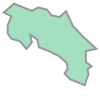

In [4]:
# La geometría de Costa Rica, con el filtrado booleano de pandas
costa_rica = paises[paises["nombre"] == "Costa Rica"]

print(costa_rica.geom_type.iloc[0])
costa_rica.geometry.iloc[0]

A escala 1:110 M, Costa Rica es un polígono de unos pocos vértices: la escala de una capa determina para qué sirve. Natural Earth publica las mismas capas a 1:50 M y 1:10 M; el repositorio del curso incluye los países de Centroamérica a 1:10 M, para mapas de la región:

(7, 10) 4326 ['Belice', 'Costa Rica', 'El Salvador', 'Guatemala', 'Honduras', 'Nicaragua', 'Panamá']


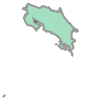

In [5]:
# Países de Centroamérica a escala 1:10 M
centroamerica = gpd.read_file(DATOS_NE + "/centroamerica.gpkg")

print(centroamerica.shape, centroamerica.crs.to_epsg(), sorted(centroamerica["nombre"]))
centroamerica[centroamerica["nombre"] == "Costa Rica"].geometry.iloc[0]

`crs.to_epsg()` retorna el código EPSG, más cómodo de comparar que el nombre completo. Las dos capas están en el mismo SRC; difieren en el detalle de las geometrías (y en el tamaño del archivo).

En la lección anterior se mencionó que geopandas también puede leer capas publicadas como servicios WFS; en el bloque siguiente se muestra cómo, con la capa de cantones del SNIT, pero el cuaderno usa archivos del repositorio, que no dependen de la disponibilidad del servicio ni de la red del aula:

```python
# Lectura de una capa WFS del SNIT (no se ejecuta en clase)
url = (
    "https://geos.snitcr.go.cr/be/IGN_5_CO/wfs?service=WFS&version=2.0.0&request=GetFeature"
    "&typeName=IGN_5_CO:limitecantonal_5k&outputFormat=application/json"
)
cantones = gpd.read_file(url)
```

*Ejercicios de esta sección: 1, en la sección de ejercicios al final del cuaderno.*

## Un GeoDataFrame es un DataFrame

Todas las operaciones de pandas funcionan igual, y el resultado conserva la geometría. Los países de América del Sur, ordenados por población:

In [6]:
# Filtrado booleano y ordenamiento, como en pandas
america_sur = paises[paises["continente"] == "América del Sur"].sort_values("poblacion_estimada", ascending=False)

print(type(america_sur))
america_sur[["codigo", "nombre", "subregion", "poblacion_estimada", "pib_millones"]]

<class 'geopandas.geodataframe.GeoDataFrame'>


,codigo,nombre,subregion,poblacion_estimada,pib_millones
29,BRA,Brasil,América del Sur,211049527,1839758
32,COL,Colombia,América del Sur,50339443,323615
9,ARG,Argentina,América del Sur,44938712,445445
31,PER,Perú,América del Sur,32510453,226848
40,VEN,Venezuela,América del Sur,28515829,482359
10,CHL,Chile,América del Sur,18952038,282318
44,ECU,Ecuador,América del Sur,17373662,107435
30,BOL,Bolivia,América del Sur,11513100,40895
156,PRY,Paraguay,América del Sur,7044636,38145
28,URY,Uruguay,América del Sur,3461734,56045


La diferencia aparece al pedir un mapa: el método `plot()`, que en pandas dibuja un gráfico de las columnas numéricas, en geopandas dibuja las **geometrías**:

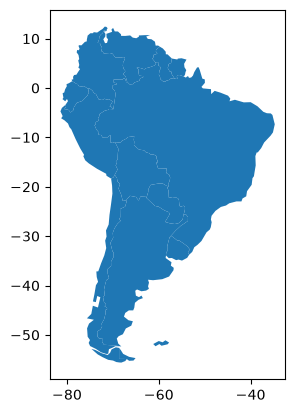

In [7]:
# Mapa rápido de América del Sur
america_sur.plot()
plt.show()

Los ejes muestran las coordenadas del SRC: grados de longitud y latitud. Con eso basta para explorar; para comunicar, el mapa se construye con el mismo patrón `fig, ax = plt.subplots()` de la [parte III](https://gf0657-programacionsig.github.io/2026-ii/pandas-graficos-matplotlib/) de la serie *pandas*.

*Ejercicios de esta sección: 2, en la sección de ejercicios al final del cuaderno.*

## De una tabla con coordenadas a un GeoDataFrame

Los datos de puntos rara vez llegan como capa geoespacial: lo usual es un CSV con dos columnas de coordenadas, como los registros de GBIF de la sección I, las ciudades de Natural Earth del repositorio o los datos que cada estudiante recopile para su tarea 3. Convertirlo en GeoDataFrame requiere dos cosas: construir los puntos a partir de las coordenadas, con `gpd.points_from_xy()`, y declarar el **SRC en que están esas coordenadas**, casi siempre WGS84:

In [8]:
# Ciudades principales del mundo, como tabla con longitud y latitud
tabla = pd.read_csv(DATOS_NE + "/ciudades.csv")

tabla.head()

,nombre,pais,codigo_pais,capital,poblacion,longitud,latitud
0,Vatican City,Vatican,VAT,True,832,12.453387,41.903282
1,San Marino,San Marino,SMR,True,29579,12.441770,43.936096
2,Vaduz,Liechtenstein,LIE,True,36281,9.516670,47.133724
3,Lobamba,eSwatini,SWZ,False,9782,31.199997,-26.466668
4,Luxembourg,Luxembourg,LUX,True,107260,6.130003,49.611660


In [9]:
# De tabla a GeoDataFrame: puntos a partir de las columnas de coordenadas, con su SRC
ciudades = gpd.GeoDataFrame(
    tabla,
    geometry=gpd.points_from_xy(tabla["longitud"], tabla["latitud"]),
    crs=4326
)

print(type(ciudades), ciudades.crs.to_epsg(), ciudades.geom_type.unique().tolist())
ciudades.head()

<class 'geopandas.geodataframe.GeoDataFrame'> 4326 ['Point']


,nombre,pais,codigo_pais,capital,poblacion,longitud,latitud,geometry
0,Vatican City,Vatican,VAT,True,832,12.453387,41.903282,POINT (12.45339 41.90328)
1,San Marino,San Marino,SMR,True,29579,12.441770,43.936096,POINT (12.44177 43.9361)
2,Vaduz,Liechtenstein,LIE,True,36281,9.516670,47.133724,POINT (9.51667 47.13372)
3,Lobamba,eSwatini,SWZ,False,9782,31.199997,-26.466668,POINT (31.2 -26.46667)
4,Luxembourg,Luxembourg,LUX,True,107260,6.130003,49.611660,POINT (6.13 49.61166)


Dos detalles que causan errores frecuentes. El orden de los argumentos de `points_from_xy()` es **x, y**, es decir, **longitud, latitud**, al revés del "latitud, longitud" con que suelen escribirse las coordenadas. Y si se omite `crs`, el GeoDataFrame queda sin SRC: los mapas se dibujan, pero `to_crs()` falla y las capas no se pueden combinar con otras. El camino inverso, de GeoDataFrame a tabla, son las propiedades `geometry.x` y `geometry.y`.

*Ejercicios de esta sección: 3, en la sección de ejercicios al final del cuaderno.*

## Mapas estáticos

`plot()` acepta los argumentos de matplotlib para el relleno (`color`), el borde (`edgecolor`, `linewidth`) y la transparencia (`alpha`), y dibuja sobre el `ax` que se le indique, lo que permite **superponer capas**: cada llamada agrega una capa al mismo mapa. Los países con las ciudades encima, con `markersize` para el tamaño de los puntos:

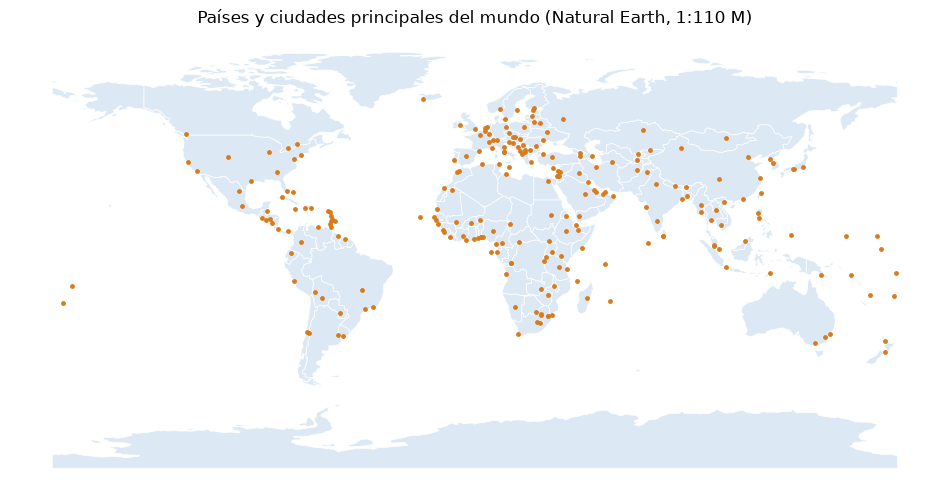

In [10]:
# Países y ciudades principales del mundo
fig, ax = plt.subplots(figsize=(12, 6))

paises.plot(ax=ax, color="#DCE9F5", edgecolor="white", linewidth=0.5)
ciudades.plot(ax=ax, color=NARANJA, markersize=6)

ax.set_title("Países y ciudades principales del mundo (Natural Earth, 1:110 M)")
ax.set_axis_off()  # en un mapa de referencia, las coordenadas de los ejes no aportan

plt.show()

Las dos capas se superponen correctamente porque están en el **mismo SRC**; qué pasa cuando no es así se muestra en la clínica de errores. El mapa, sin embargo, tiene un defecto: está "estirado". Es el aspecto de un SRC geográfico dibujado directamente, con un grado de longitud tan ancho como uno de latitud en toda la figura, lo que deforma todo lo que está lejos del ecuador. Un mapa del mundo se dibuja en una proyección.

*Ejercicios de esta sección: 2, en la sección de ejercicios al final del cuaderno.*

## Sistemas de referencia de coordenadas

El SRC de una capa se consulta en `crs` y se cambia, **reproyectando** todas sus geometrías, con `to_crs()`, que recibe un código EPSG y retorna una capa nueva. Los países en Equal Earth, una proyección que conserva las áreas, y en Mercator, que conserva las formas:

In [11]:
# Reproyección a Equal Earth (EPSG:8857) y a Web Mercator (EPSG:3857)
paises_ee = paises.to_crs(8857)
paises_merc = paises.to_crs(3857)

print(paises_ee.crs.name, "|", paises_merc.crs.name)
print("Extensión en WGS84 (grados):     ", paises.total_bounds.round(1))
print("Extensión en Equal Earth (metros):", paises_ee.total_bounds.round(0))

WGS 84 / Equal Earth Greenwich | WGS 84 / Pseudo-Mercator
Extensión en WGS84 (grados):      [-180.   -90.   180.    83.6]
Extensión en Equal Earth (metros): [-16923980.  -8392928.  16923980.   8316222.]


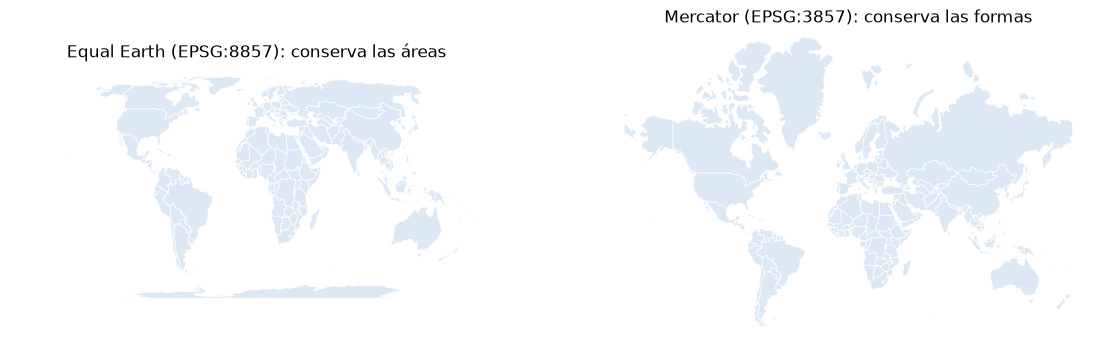

In [12]:
# El mismo mapa en las dos proyecciones
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

paises_ee.plot(ax=ax1, color="#DCE9F5", edgecolor="white", linewidth=0.5)
ax1.set_title("Equal Earth (EPSG:8857): conserva las áreas")

paises_merc[paises_merc["nombre"] != "Antártida"].plot(ax=ax2, color="#DCE9F5", edgecolor="white", linewidth=0.5)
ax2.set_ylim(-9e6, 1.9e7)
ax2.set_title("Mercator (EPSG:3857): conserva las formas")

for ax in (ax1, ax2):
    ax.set_axis_off()

plt.show()

`total_bounds` retorna la extensión de la capa como `[xmin, ymin, xmax, ymax]`: los mismos países, en grados y en metros desde el origen de la proyección. Y las dos proyecciones cuentan historias distintas sobre Groenlandia. No es un detalle menor: en setiembre de 2026 la Asamblea General de las Naciones Unidas aprobó la resolución "Correct the map", que alienta a usar Equal Earth u otras proyecciones equivalentes en lugar de Mercator cuando importe el tamaño relativo de las regiones (ver la lección anterior).

La consecuencia práctica más importante del SRC es la **medición**. El área de una geometría se calcula con `area`, en las unidades al cuadrado del SRC: grados cuadrados (sin sentido) en WGS84 y metros cuadrados en cualquier SRC proyectado, pero con la deformación de la proyección. Groenlandia y Brasil en las dos:

In [13]:
# Área de Groenlandia y Brasil, en km², según la proyección
seleccion = paises["nombre"].isin(["Groenlandia", "Brasil"])

pd.DataFrame({
    "nombre": paises.loc[seleccion, "nombre"],
    "area_equal_earth_km2": (paises_ee.loc[seleccion].area / 1_000_000).round(0),
    "area_mercator_km2": (paises_merc.loc[seleccion].area / 1_000_000).round(0)
})

,nombre,area_equal_earth_km2,area_mercator_km2
22,Groenlandia,2206879.0,36285503.0
29,Brasil,8508179.0,9059541.0


En Equal Earth, Brasil es casi cuatro veces más grande que Groenlandia, como en la realidad (8,5 contra 2,2 millones de km²); en Mercator, Groenlandia resulta cuatro veces más grande que Brasil. Para medir áreas a escala mundial se usa una proyección **equivalente**, como Equal Earth; para medir en un país, una proyección local. La de Costa Rica es CR-SIRGAS / CRTM05 (EPSG:8908):

In [14]:
# Área de los países de Centroamérica en CRTM05, la proyección local de Costa Rica
centroamerica_crtm05 = centroamerica.to_crs(8908)
centroamerica_crtm05["area_km2"] = (centroamerica_crtm05.area / 1_000_000).round(0)

centroamerica_crtm05[["nombre", "area_km2"]].sort_values("area_km2", ascending=False)

,nombre,area_km2
1,Nicaragua,128735.0
4,Honduras,112497.0
3,Guatemala,110073.0
6,Panamá,74915.0
0,Costa Rica,51152.0
5,Belice,22433.0
2,El Salvador,20679.0


Costa Rica mide unos 51 100 km², la cifra oficial. CRTM05 está diseñada para Costa Rica, y la deformación crece con la distancia a su meridiano central (−84°): el área de Guatemala, a unos 600 km, sale ya un 1 % mayor que en Equal Earth, y la de México, a más de 2 000 km, no sería confiable. La regla: medir en el SRC diseñado para la región de los datos.

*Ejercicios de esta sección: 3 y 4, en la sección de ejercicios al final del cuaderno.*

## Unión con datos tabulares

Las capas de Natural Earth traen la geometría y unos pocos atributos; los indicadores actuales están en el CSV del Banco Mundial. Ambas fuentes identifican los países con códigos de tres letras, así que se unen con `merge()`, exactamente como en la [parte II](https://gf0657-programacionsig.github.io/2026-ii/pandas-agrupacion-uniones/) de la serie *pandas*. El resultado es un GeoDataFrame **siempre que el GeoDataFrame esté a la izquierda**, es decir, que sea el objeto sobre el que se llama a `merge()`:

In [15]:
# Indicadores del desarrollo mundial de 2024, del Banco Mundial
indicadores = pd.read_csv(DATOS_BM + "/indicadores-2024.csv")

print(indicadores.shape)
indicadores.head()

(217, 11)


,codigo,pais,region,grupo_ingreso,poblacion,crecimiento_poblacion,area_km2,pib_per_capita,esperanza_vida,poblacion_urbana_pct,usuarios_internet_pct
0,ABW,Aruba,América Latina y el Caribe,Ingreso alto,107995,0.59,180.0,38590.6,76.5,61.8,NaN
1,AFG,Afganistán,"Oriente Medio, Norte de África, Afganistán y P...",Países de ingreso bajo,42647492,2.84,652230.0,416.9,66.3,25.7,16.1
2,AGO,Angola,África al sur del Sahara,Países de ingreso mediano bajo,37885849,3.04,1246700.0,2720.8,64.8,70.7,40.7
3,ALB,Albania,Europa y Asia central,Ingreso mediano alto,2377128,-1.44,27400.0,11374.0,79.8,58.5,85.9
4,AND,Andorra,Europa y Asia central,Ingreso alto,81938,1.33,470.0,49357.4,84.2,88.9,94.4


In [16]:
# Unión por código de país; el GeoDataFrame va a la izquierda para conservar la geometría
paises_bm = paises_ee.merge(indicadores, on="codigo", how="left")

print(type(paises_bm))
print(paises_bm.shape)
paises_bm[["codigo", "nombre", "pais", "poblacion", "pib_per_capita", "esperanza_vida"]].head()

<class 'geopandas.geodataframe.GeoDataFrame'>
(177, 20)


,codigo,nombre,pais,poblacion,pib_per_capita,esperanza_vida
0,FJI,Fiyi,Fiji,928784.0,6425.7,67.5
1,TZA,Tanzania,Tanzanía,68560157.0,1192.6,67.2
2,SAH,Sahara Occidental,NaN,NaN,NaN,NaN
3,CAN,Canadá,Canadá,41262329.0,55015.7,82.1
4,USA,Estados Unidos,Estados Unidos,340003797.0,86169.7,78.9


Como siempre, se verifica la unión: ¿cuáles países quedaron sin datos del Banco Mundial?

In [17]:
# Países de Natural Earth sin pareja en el Banco Mundial
sin_pareja = paises_bm[paises_bm["poblacion"].isna()]

print(len(sin_pareja))
sin_pareja[["codigo", "nombre", "poblacion_estimada"]]

10


,codigo,nombre,poblacion_estimada
2,SAH,Sahara Occidental,603253
20,FLK,Islas Malvinas,3398
23,ATF,Tierras Australes y Antárticas Francesas,140
79,PSX,Palestina,4685306
140,TWN,República de China,23568378
159,ATA,Antártida,4490
160,CYN,República Turca del Norte de Chipre,326000
167,SOL,Somalilandia,5096159
174,KOS,Kosovo,1794248
176,SDS,Sudán del Sur,11062113


Diez países sin pareja, de dos clases. Algunos no están en el Banco Mundial (la Antártida, Taiwán, Somalilandia y otros territorios sin reconocimiento general). Pero Kosovo, Palestina y Sudán del Sur sí están: con **otro código** (`XKX`, `PSE` y `SSD` en lugar de `KOS`, `PSX` y `SDS`, como advierte el LEEME). Es el mismo problema de la unión por nombre de la parte II: las llaves que no coinciden se corrigen antes de unir, aquí con `replace()`:

In [18]:
# Corrección de los tres códigos y nueva unión
codigos_bm = {"KOS": "XKX", "PSX": "PSE", "SDS": "SSD"}
paises_ee["codigo"] = paises_ee["codigo"].replace(codigos_bm)

paises_bm = paises_ee.merge(indicadores, on="codigo", how="left")

print("Sin datos del Banco Mundial:", paises_bm["poblacion"].isna().sum())
paises_bm[paises_bm["poblacion"].isna()]["nombre"].tolist()

Sin datos del Banco Mundial: 7


['Sahara Occidental',
 'Islas Malvinas',
 'Tierras Australes y Antárticas Francesas',
 'República de China',
 'Antártida',
 'República Turca del Norte de Chipre',
 'Somalilandia']

Los siete que quedan no tienen datos en la fuente: en los mapas aparecerán como "sin datos", lo que es correcto. Y la unión permite verificar las áreas calculadas contra la superficie que publica el Banco Mundial:

In [19]:
# Área calculada en Equal Earth contra la superficie terrestre del Banco Mundial
paises_bm["area_calculada_km2"] = (paises_bm.area / 1_000_000).round(0)
paises_bm["diferencia_pct"] = ((paises_bm["area_calculada_km2"] - paises_bm["area_km2"]) / paises_bm["area_km2"] * 100).round(1)

paises_bm[["nombre", "area_calculada_km2", "area_km2", "diferencia_pct"]].sort_values("diferencia_pct", key=abs, ascending=False).head()

,nombre,area_calculada_km2,area_km2,diferencia_pct
22,Groenlandia,2206879.0,410450.0,437.7
149,Brunéi,10698.0,5270.0,103.0
19,Bahamas,15592.0,10010.0,55.8
175,Trinidad y Tobago,7742.0,5130.0,50.9
89,Vanuatu,7489.0,12190.0,-38.6


La mitad de los países difiere menos de un 3 %, lo razonable para geometrías a 1:110 M. Los casos extremos tienen explicación: el Banco Mundial reporta la superficie **terrestre**, sin aguas interiores ni, en Groenlandia, la capa de hielo (410 000 km² de los 2,2 millones); y en las islas pequeñas, como Brunéi o Bahamas, la geometría a 1:110 M es demasiado gruesa. Verificar los datos aunque provengan de fuentes oficiales, y entender por qué difieren, es parte del trabajo.

*Ejercicios de esta sección: 4 y 5, en la sección de ejercicios al final del cuaderno.*

## Mapas de coropletas

Un **mapa de coropletas** colorea cada polígono según el valor de una variable. En geopandas basta con indicar la columna en `plot()`; `legend=True` agrega la barra de color y `cmap` elige la paleta (las de matplotlib: `"YlOrRd"`, `"Blues"`, `"viridis"`...). El PIB per cápita:

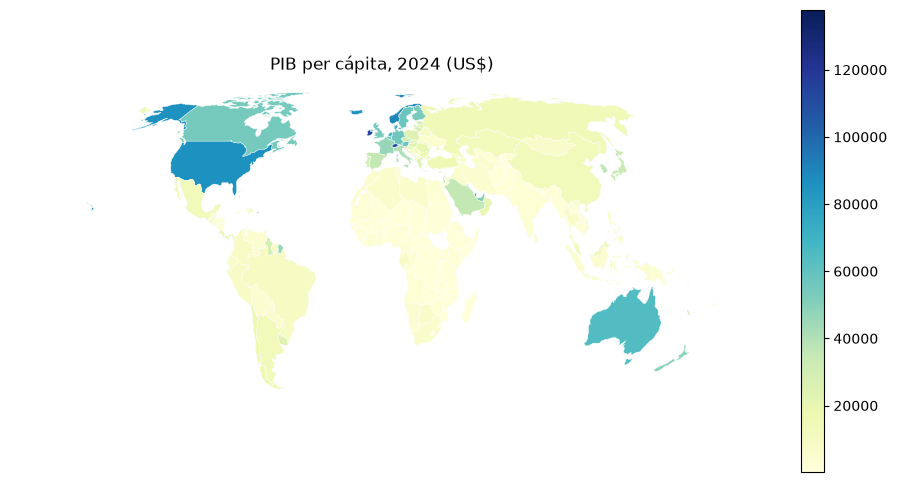

In [20]:
# PIB per cápita por país: primer intento
fig, ax = plt.subplots(figsize=(12, 6))

paises_bm.plot(ax=ax, column="pib_per_capita", cmap="YlGnBu", edgecolor="white", linewidth=0.3, legend=True)

ax.set_title("PIB per cápita, 2024 (US$)")
ax.set_axis_off()

plt.show()

Dos problemas. El mapa es casi todo amarillo: unos pocos países muy ricos estiran la escala y el resto queda indistinguible, la misma asimetría que en la parte III obligó a usar escalas logarítmicas, y la solución es la misma: `norm=LogNorm()` aplica la escala logarítmica al color. Y los países sin datos desaparecen del mapa: `missing_kwds` indica cómo dibujarlos. Además, `legend_kwds` ajusta la leyenda (aquí, su título y su tamaño):

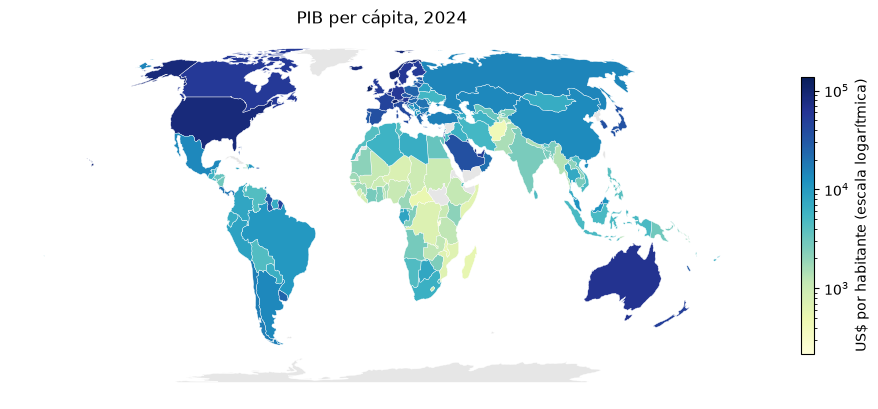

In [21]:
# PIB per cápita, con escala logarítmica de color y países sin datos
fig, ax = plt.subplots(figsize=(12, 6))

paises_bm.plot(
    ax=ax, column="pib_per_capita", cmap="YlGnBu", edgecolor="white", linewidth=0.3,
    norm=LogNorm(vmin=paises_bm["pib_per_capita"].min(), vmax=paises_bm["pib_per_capita"].max()),
    legend=True, legend_kwds={"label": "US$ por habitante (escala logarítmica)", "shrink": 0.6},
    missing_kwds={"color": "#E6E6E6", "label": "Sin datos"}
)

ax.set_title("PIB per cápita, 2024")
ax.set_axis_off()

plt.show()

Ahora se lee el gradiente completo, de los 200 dólares de Burundi a los 140 000 de Luxemburgo, y la Antártida, Groenlandia y los demás países sin datos quedan en gris. Para una variable con un valor central significativo, como el crecimiento de la población (positivo o negativo), lo adecuado es una paleta **divergente** (`"RdBu"`, `"PiYG"`, `"BrBG"`) centrada en ese valor, con `matplotlib.colors.TwoSlopeNorm(vcenter=0)`; eso se practica en los ejercicios.

### Clasificación

La alternativa a la escala continua es **clasificar** los valores en pocas clases, cada una con un color, como hacen los SIG de escritorio. El argumento `scheme` lo hace con la biblioteca mapclassify: `"Quantiles"` pone el mismo número de países en cada clase, `"NaturalBreaks"` busca los cortes naturales de la distribución y `"EqualInterval"` usa intervalos iguales; `k` es el número de clases. Las clases se listan en la leyenda, que al ser discreta se coloca con `legend_kwds` como una leyenda normal de matplotlib:

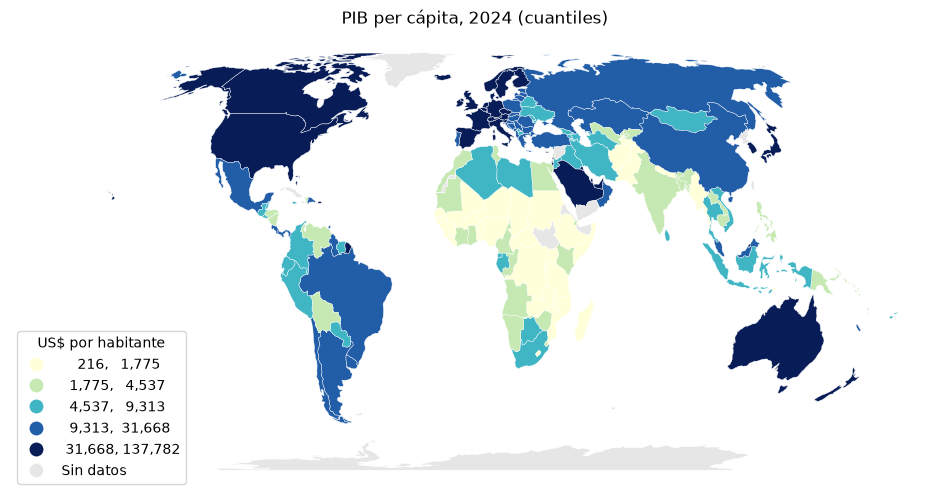

In [22]:
# PIB per cápita clasificado en cinco cuantiles (requiere mapclassify)
fig, ax = plt.subplots(figsize=(12, 6))

paises_bm.plot(
    ax=ax, column="pib_per_capita", cmap="YlGnBu", edgecolor="white", linewidth=0.3,
    scheme="Quantiles", k=5,
    legend=True, legend_kwds={"title": "US$ por habitante", "loc": "lower left", "fmt": "{:,.0f}"},
    missing_kwds={"color": "#E6E6E6", "label": "Sin datos"}
)

ax.set_title("PIB per cápita, 2024 (cuantiles)")
ax.set_axis_off()

plt.show()

Cada clase tiene unos 33 países, y los límites de las clases (unos 1 800, 4 500, 9 300 y 31 700 dólares) resumen la distribución: tres de cada cinco países tienen un PIB per cápita menor de 9 300 dólares. La clasificación simplifica la lectura a costa de ocultar las diferencias dentro de cada clase; el método elegido cambia el mapa, por lo que debe indicarse en el título o en la leyenda.

*Ejercicios de esta sección: 5 y 6, en la sección de ejercicios al final del cuaderno.*

## Mapas interactivos

`explore()` produce un **mapa interactivo** con folium, la biblioteca de mapas web de la semana 12, con los mismos argumentos principales de `plot()` (`column`, `cmap`, `legend`). El mapa se puede desplazar y acercar, y al pasar el cursor por un polígono aparecen sus atributos. geopandas reproyecta la capa a WGS84 automáticamente, cualquiera que sea su SRC: los mapas web siempre están en Web Mercator, con la deformación de Groenlandia incluida. Los argumentos más útiles: `tooltip`, las columnas que se muestran al pasar el cursor; `popup`, las que se muestran al hacer clic; `tiles`, el **mapa base** (`"OpenStreetMap"`, el predeterminado y gratuito; otros, como los de CARTO o Esri, requieren una clave o tienen condiciones de uso); `style_kwds`, el estilo de los polígonos; y `location` y `zoom_start`, el centro y el acercamiento iniciales:

In [23]:
# Esperanza de vida al nacer por país, en un mapa interactivo
mapa = paises_bm.explore(
    column="esperanza_vida",
    cmap="viridis",
    tooltip=["nombre", "continente", "poblacion", "esperanza_vida"],
    popup=True,  # todas las columnas, al hacer clic
    tiles="OpenStreetMap",
    style_kwds={"color": "white", "weight": 0.5},
    missing_kwds={"color": "#E6E6E6"},
    legend_kwds={"caption": "Esperanza de vida al nacer, 2024 (años)"},
    location=[20, 0], zoom_start=2
)

mapa

`scheme` y `k` funcionan también aquí (con mapclassify). Para superponer capas, la segunda llamada a `explore()` recibe el mapa anterior en el argumento `m`:

In [24]:
# Ciudades sobre los países, en un mapa interactivo
mapa = paises.explore(
    tooltip=["nombre", "continente"],
    tiles="OpenStreetMap",
    color="#DCE9F5",
    style_kwds={"color": "white", "weight": 0.5, "fillOpacity": 0.7},
    location=[20, 0], zoom_start=2
)

ciudades.explore(m=mapa, color=NARANJA, marker_kwds={"radius": 3}, tooltip=["nombre", "pais", "poblacion"])

mapa

La tabla 1 resume los argumentos de los dos métodos de mapas.

<figure style="text-align: center; margin: 20px 0;">
    <figcaption><strong>Tabla 1</strong>. Argumentos más usados de <code>plot()</code> y <code>explore()</code>. Fuente: elaboración propia con base en GeoPandas developers (s. f.-b).</figcaption>
    <table class="table table-bordered table-striped" style="margin: 0 auto;">
    <thead>
      <tr><th>Propósito</th><th><code>plot()</code> (matplotlib, estático)</th><th><code>explore()</code> (folium, interactivo)</th></tr>
    </thead>
    <tbody>
      <tr><td>Colorear por una variable</td><td><code>column</code>, <code>cmap</code>, <code>legend</code>, <code>norm</code></td><td><code>column</code>, <code>cmap</code>, <code>legend</code>, <code>vmin</code>, <code>vmax</code></td></tr>
      <tr><td>Clasificar</td><td><code>scheme</code>, <code>k</code></td><td><code>scheme</code>, <code>k</code></td></tr>
      <tr><td>Valores faltantes</td><td><code>missing_kwds</code></td><td><code>missing_kwds</code></td></tr>
      <tr><td>Color y borde fijos</td><td><code>color</code>, <code>edgecolor</code>, <code>linewidth</code>, <code>alpha</code></td><td><code>color</code>, <code>style_kwds</code> (<code>color</code>, <code>weight</code>, <code>fillOpacity</code>)</td></tr>
      <tr><td>Puntos</td><td><code>markersize</code>, <code>marker</code></td><td><code>marker_kwds</code> (<code>radius</code>)</td></tr>
      <tr><td>Superponer capas</td><td><code>ax=ax</code></td><td><code>m=mapa</code></td></tr>
      <tr><td>Extensión inicial</td><td><code>ax.set_xlim()</code>, <code>ax.set_ylim()</code></td><td><code>location</code>, <code>zoom_start</code></td></tr>
      <tr><td>Información de cada entidad</td><td>—</td><td><code>tooltip</code>, <code>popup</code></td></tr>
      <tr><td>Mapa base</td><td>— (ver contextily)</td><td><code>tiles</code></td></tr>
      <tr><td>Leyenda</td><td><code>legend_kwds</code> (<code>label</code>, <code>shrink</code>, <code>title</code>, <code>loc</code>)</td><td><code>legend_kwds</code> (<code>caption</code>)</td></tr>
    </tbody>
    </table>
</figure>

*Ejercicios de esta sección: 7 y 8, en la sección de ejercicios al final del cuaderno.*

## Guardar una capa

`to_file()` escribe un GeoDataFrame en el formato que indique la extensión o el argumento `driver`. GeoPackage es la opción recomendada; GeoJSON es útil para la web (y conviene guardarlo en WGS84, como exige su especificación):

In [25]:
# Los países de América del Sur, con los indicadores, en GeoPackage y en GeoJSON
america_sur_bm = paises_bm[paises_bm["continente"] == "América del Sur"]

america_sur_bm.to_file("america-sur.gpkg", driver="GPKG")
america_sur_bm.to_crs(4326).to_file("america-sur.geojson", driver="GeoJSON")

# Comprobación: se vuelve a leer el GeoPackage
gpd.read_file("america-sur.gpkg").shape

(13, 22)

*Ejercicios de esta sección: 9, en la sección de ejercicios al final del cuaderno.*

## Clínica de errores

Los tres errores más frecuentes al empezar con geopandas, provocados a propósito. El primero no da ningún mensaje:

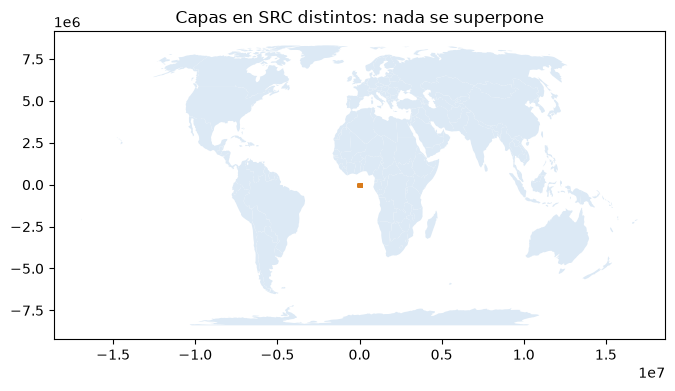

In [26]:
# Error silencioso: dos capas en SRC distintos en el mismo mapa.
# Las ciudades en WGS84 (grados) sobre los países en Equal Earth (metros): los puntos
# quedan todos amontonados en el origen, a la escala de los grados.
fig, ax = plt.subplots(figsize=(8, 4))
paises_ee.plot(ax=ax, color="#DCE9F5")
ciudades.plot(ax=ax, color=NARANJA, markersize=5)
ax.set_title("Capas en SRC distintos: nada se superpone")
plt.show()

In [27]:
# UserWarning: "Geometry is in a geographic CRS. Results from 'area' are likely incorrect."
# El área en WGS84 se calcula en grados cuadrados; hay que reproyectar antes (to_crs(8857))
paises.area.head(3)

/tmp/ipykernel_38626/361482190.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  paises.area.head(3)


0     1.639511
1    76.301964
2     8.603984
dtype: float64

In [28]:
# AttributeError: 'DataFrame' object has no attribute 'explore'
# pd.merge() con el DataFrame a la izquierda retorna un DataFrame: la geometría queda como una columna
# cualquiera y se pierden los métodos geoespaciales. Debe ser paises_ee.merge(indicadores, ...).
union = pd.merge(indicadores, paises_ee, on="codigo")
print(type(union))
union.explore()

<class 'pandas.DataFrame'>


AttributeError: 'DataFrame' object has no attribute 'explore'

## Asistentes de IA para generar mapas

Las pautas de las partes II y III de la serie *pandas* aplican: describir el GeoDataFrame en el contexto (columnas y, ahora, también el SRC), pedir el patrón del curso y verificar el resultado. Para los mapas hay tres comprobaciones específicas: que el código no mezcle SRC (todas las capas en el mismo, y reproyectadas antes de medir), que la escala de color sea adecuada para la distribución de la variable (logarítmica o clasificada si es asimétrica, divergente si tiene un valor central) y que la leyenda tenga unidades. Un prompt de ejemplo:

> Actúe como asistente de visualización de datos geoespaciales con geopandas y matplotlib **(rol)**. Tengo un GeoDataFrame llamado `paises_bm`, con un polígono por país del mundo en el SRC EPSG:8857 (Equal Earth) y las columnas `nombre` (texto), `continente` (texto), `poblacion` (entero) y `crecimiento_poblacion` (decimal: crecimiento anual de la población en 2024, en porcentaje, entre −5 y 7, con valores faltantes) **(contexto)**. Escriba el código de un mapa de coropletas del crecimiento de la población, con una paleta divergente centrada en cero, los países sin datos en gris, barra de color con etiqueta en español, título, bordes blancos y sin ejes **(tarea)**. Use el patrón `fig, ax = plt.subplots()` y `paises_bm.plot(ax=ax, ...)`, y termine con `plt.show()` **(formato)**.

## Resumen

- geopandas extiende pandas con la **GeoSeries** (columna de geometrías de shapely) y el **GeoDataFrame** (DataFrame con una columna de geometría activa); todas las operaciones de pandas funcionan y conservan la geometría si el GeoDataFrame está a la izquierda en `merge()`.
- `gpd.read_file()` lee cualquier formato vectorial (desde rutas o URL) y `to_file()` escribe, preferiblemente en **GeoPackage**. `crs`, `geom_type`, `geometry` y `total_bounds` describen la parte geoespacial. La **escala** de la capa determina su uso.
- Una tabla con coordenadas se convierte en GeoDataFrame con `gpd.points_from_xy(longitud, latitud)` y `crs=4326`: en ese orden y con el SRC declarado.
- `to_crs(codigo)` **reproyecta**. Un mapa del mundo se dibuja en una proyección (Equal Earth, EPSG:8857), no en WGS84; para medir áreas se usa una proyección equivalente a escala mundial o la local del país (CR-SIRGAS / CRTM05, EPSG:8908, en Costa Rica); para superponer capas, todas deben estar en el mismo SRC.
- Las uniones se verifican: las llaves que no coinciden (los códigos de Kosovo, Palestina y Sudán del Sur) se corrigen con `replace()` antes de unir.
- `plot()` dibuja mapas estáticos con matplotlib, superponiendo capas con `ax`; con `column` produce **coropletas**, cuya escala de color se ajusta con `norm=LogNorm()` para variables asimétricas, con paletas divergentes y `TwoSlopeNorm` para variables con un valor central, o con `scheme` y `k` para **clasificar** (mapclassify); `missing_kwds` dibuja los valores faltantes.
- `explore()` produce mapas **interactivos** con folium, con `tooltip`, `popup`, `tiles`, `location`, `zoom_start` y `m` para superponer.

## Ejercicios

Los ejercicios se agrupan según la sección del cuaderno a la que corresponden; se recomienda realizarlos al concluir la sección respectiva. Resuélvalos en este mismo cuaderno (en su copia de Colab o local), después de ejecutar las celdas de las secciones anteriores. Varios incluyen una **celda de verificación** que examina el objeto creado: para que funcione, nombre los objetos como se indica en el enunciado y ejecute la celda tal cual después de resolver el ejercicio (en la versión publicada muestra un recordatorio, porque los ejercicios no están resueltos). Las [soluciones de estos ejercicios](https://gf0657-programacionsig.github.io/2026-ii/soluciones-geopandas-datos-vectoriales) se publican después de la clase correspondiente.

### Carga y exploración

1. Cargue en `aeropuertos` la capa de aeropuertos de Natural Earth (`DATOS_NE + "/aeropuertos.gpkg"`) e imprima su SRC, su número de filas y sus tipos de geometría. Luego, con `paises`, guarde en `paises_por_continente` cuántos países tiene cada continente (con `value_counts()`). ¿Cuál continente tiene más países en la capa?

In [29]:
# Celda de verificación del ejercicio 1: ejecútela tal cual
try:
    assert isinstance(aeropuertos, gpd.GeoDataFrame) and len(aeropuertos) == 893, "aeropuertos debe ser un GeoDataFrame de 893 filas"
    assert paises_por_continente.sum() == 177, "Los países por continente deben sumar 177"
    assert paises_por_continente.idxmax() == "África", "África es el continente con más países en la capa"
    print("Ejercicio 1: ¡correcto!")
except NameError:
    print("Aún no se han definido aeropuertos y paises_por_continente (ejercicio 1).")

Aún no se han definido aeropuertos y paises_por_continente (ejercicio 1).


2. Cree en `africa` el GeoDataFrame con los países de África, en la proyección Equal Earth, y dibuje en `ax_2` un mapa estático con los países en color claro, los límites en blanco, las ciudades del continente encima (filtre `ciudades` por los códigos de país de `africa`, y recuerde el SRC), título y sin ejes. ¿Cuántos países tiene el continente en la capa?

In [30]:
# Celda de verificación del ejercicio 2: ejecútela tal cual
try:
    assert isinstance(africa, gpd.GeoDataFrame) and len(africa) == 51, "africa debe ser un GeoDataFrame con los 51 países del continente"
    assert africa.crs.to_epsg() == 8857, "africa debe estar en Equal Earth (EPSG:8857)"
    assert ax_2.get_title(), "Falta el título"
    assert not ax_2.axison, "Los ejes deben estar ocultos (set_axis_off())"
    assert len(ax_2.collections) >= 2, "Faltan las ciudades sobre los países"
    print("Ejercicio 2: ¡correcto!")
except NameError:
    print("Aún no se han definido africa y ax_2 (ejercicio 2).")

Aún no se han definido africa y ax_2 (ejercicio 2).


### Coordenadas y sistemas de referencia

3. Reproyecte `ciudades` a Web Mercator en `ciudades_merc` y a Equal Earth en `ciudades_ee`. Imprima las coordenadas de San José de Costa Rica en los tres SRC (`geometry.x` y `geometry.y`) y explique en una celda de texto por qué los tres pares de números representan el mismo lugar.

In [31]:
# Celda de verificación del ejercicio 3: ejecútela tal cual
try:
    assert ciudades_merc.crs.to_epsg() == 3857, "ciudades_merc debe estar en EPSG:3857"
    assert ciudades_ee.crs.to_epsg() == 8857, "ciudades_ee debe estar en EPSG:8857"
    assert len(ciudades_merc) == len(ciudades) == len(ciudades_ee), "La reproyección no cambia el número de filas"
    print("Ejercicio 3: ¡correcto!")
except NameError:
    print("Aún no se han definido ciudades_merc y ciudades_ee (ejercicio 3).")

Aún no se han definido ciudades_merc y ciudades_ee (ejercicio 3).


4. Una `centroamerica_crtm05` con los indicadores del Banco Mundial en `centroamerica_bm` (por `codigo`, con el GeoDataFrame a la izquierda) y agregue la columna `diferencia_pct` entre el área calculada en CRTM05 (`area_km2` de la capa) y la superficie terrestre del Banco Mundial (que, por el sufijo de la unión, queda como `area_km2_y` si no renombra antes; el enunciado acepta cualquier solución que calcule la diferencia). ¿En cuál país es mayor la diferencia y por qué? Pista: el Banco Mundial reporta superficie **terrestre**; piense qué tiene ese país que los demás no. Luego calcule el área de cada país también en Equal Earth y compárela con la de CRTM05: ¿cuánto de la diferencia se debe a la proyección y en cuál país es mayor ese efecto?

In [32]:
# Celda de verificación del ejercicio 4: ejecútela tal cual
try:
    assert isinstance(centroamerica_bm, gpd.GeoDataFrame), "centroamerica_bm debe ser un GeoDataFrame (¿el GeoDataFrame quedó a la izquierda?)"
    assert len(centroamerica_bm) == 7 and "poblacion" in centroamerica_bm.columns, "Deben ser 7 países con los datos del Banco Mundial"
    assert "diferencia_pct" in centroamerica_bm.columns, "Falta la columna diferencia_pct"
    assert centroamerica_bm.set_index("nombre")["diferencia_pct"].abs().idxmax() == "Nicaragua", "La mayor diferencia debería estar en Nicaragua"
    print("Ejercicio 4: ¡correcto!")
except NameError:
    print("Aún no se ha definido centroamerica_bm (ejercicio 4).")

Aún no se ha definido centroamerica_bm (ejercicio 4).


### Mapas de coropletas

5. En `ax_5`, dibuje un mapa de coropletas de la **esperanza de vida** de los países de América del Sur (`america_sur_bm`), con la paleta `"viridis"`, barra de color con etiqueta, los países sin datos en gris, el nombre de cada país como texto sobre su polígono (pista: `representative_point()` da un punto dentro de cada polígono, y `ax.annotate()` o `ax.text()` escriben en él) y título.

In [33]:
# Celda de verificación del ejercicio 5: ejecútela tal cual
try:
    assert ax_5.get_title(), "Falta el título"
    assert len(ax_5.texts) == len(america_sur_bm), "Debe haber un texto por país"
    assert len(ax_5.figure.axes) >= 2, "Falta la barra de color (legend=True)"
    print("Ejercicio 5: ¡correcto!")
except NameError:
    print("Aún no se ha definido ax_5 (ejercicio 5).")

Aún no se ha definido ax_5 (ejercicio 5).


6. En `ax_6`, dibuje un mapa de coropletas del crecimiento anual de la población por país (`crecimiento_poblacion` de `paises_bm`), con una paleta divergente centrada en cero (con `norm=TwoSlopeNorm(vcenter=0, vmin=-4, vmax=4)`, de `matplotlib.colors`), los países sin datos en gris, barra de color con etiqueta y título. ¿En qué regiones del mundo decrece la población? ¿Y dónde crece más rápido? Interprete el patrón geográfico en una celda de texto.

In [34]:
# Celda de verificación del ejercicio 6: ejecútela tal cual
try:
    assert ax_6.get_title(), "Falta el título"
    assert len(ax_6.collections) >= 1, "El mapa debe tener polígonos dibujados"
    colorbar = ax_6.figure.axes[-1]
    assert colorbar is not ax_6 and colorbar.get_ylabel(), "Falta la barra de color con etiqueta"
    print("Ejercicio 6: ¡correcto!")
except NameError:
    print("Aún no se ha definido ax_6 (ejercicio 6).")

Aún no se ha definido ax_6 (ejercicio 6).


### Mapas interactivos

7. Cree en `mapa_7` un mapa interactivo de `paises_bm` clasificado en cinco clases por **cuantiles** del porcentaje de usuarios de Internet (`usuarios_internet_pct`), con la paleta `"YlGnBu"`, el nombre del país, el continente y el porcentaje en la etiqueta emergente, los países sin datos en gris, el mapa base de OpenStreetMap, bordes blancos y el centro y acercamiento iniciales del cuaderno. Si trabaja en Colab, instale antes mapclassify. Compare el mapa con una versión de escala continua: ¿qué muestra la clasificación que la escala continua no, y viceversa?

In [35]:
# Celda de verificación del ejercicio 7: ejecútela tal cual
try:
    import folium
    assert isinstance(mapa_7, folium.Map), "mapa_7 debe ser un mapa de folium (resultado de explore())"
    print("Ejercicio 7: ¡correcto!")
except NameError:
    print("Aún no se ha definido mapa_7 (ejercicio 7).")

Aún no se ha definido mapa_7 (ejercicio 7).


8. Construya a mano un DataFrame con tres lugares que conozca (por ejemplo, su casa, la Escuela de Geografía y un sitio de interés), con columnas `nombre`, `longitud` y `latitud` obtenidas de Google Maps u OpenStreetMap, y conviértalo en el GeoDataFrame `lugares` con el SRC correcto. Muéstrelo en un mapa interactivo sobre `centroamerica` y verifique que los puntos caen donde deben. Luego reproyecte `lugares` a CR-SIRGAS / CRTM05 y observe las coordenadas resultantes: ¿en qué unidades están y qué tan grandes son los números?

In [36]:
# Celda de verificación del ejercicio 8: ejecútela tal cual
try:
    assert isinstance(lugares, gpd.GeoDataFrame) and len(lugares) >= 3, "lugares debe ser un GeoDataFrame con al menos 3 filas"
    assert lugares.crs is not None and lugares.crs.to_epsg() == 4326, "Las coordenadas de Google Maps/OSM están en WGS84: crs=4326"
    assert (lugares.geometry.x < 0).all() and (lugares.geometry.y > 0).all(), "¿Longitud y latitud en el orden correcto? En Costa Rica x es negativa e y positiva"
    print("Ejercicio 8: ¡correcto!")
except NameError:
    print("Aún no se ha definido lugares (ejercicio 8).")

Aún no se ha definido lugares (ejercicio 8).


### Guardar, predecir y asistentes

9. Guarde `africa` con los indicadores del Banco Mundial (únalos primero, con los códigos ya corregidos) en un GeoPackage `africa.gpkg` y vuelva a leerlo en `africa_leido`. Compruebe que el SRC y el número de filas se conservaron.

In [37]:
# Celda de verificación del ejercicio 9: ejecútela tal cual
try:
    import os
    assert len(africa_leido) == 51 and africa_leido.crs == africa.crs, "El archivo leído debe tener 51 países y el mismo SRC"
    assert "poblacion" in africa_leido.columns, "El archivo debe incluir los indicadores del Banco Mundial"
    assert os.path.exists("africa.gpkg"), "No se encuentra el archivo africa.gpkg"
    print("Ejercicio 9: ¡correcto!")
except NameError:
    print("Aún no se ha definido africa_leido (ejercicio 9).")

Aún no se ha definido africa_leido (ejercicio 9).


10. **Prediga antes de ejecutar**: ¿qué dibuja el siguiente código? ¿De qué color es cada país, cuántos colores hay y qué muestra la leyenda? Escriba su predicción en una celda de texto y luego ejecútelo.

```python
fig, ax = plt.subplots(figsize=(12, 6))
paises_ee.plot(ax=ax, column="continente", legend=True, edgecolor="white", linewidth=0.3)
ax.set_axis_off()
plt.show()
```

<details>
<summary>Explicación (ábrala después de predecir)</summary>

Cuando `column` es una columna de **texto**, geopandas la trata como categórica: asigna un color distinto a cada valor (ocho, uno por continente, con la paleta categórica por defecto) y la leyenda es una lista de categorías, no una barra de color. Es la forma más rápida de ver a qué grupo pertenece cada polígono. Con `categorical=True` se fuerza el mismo comportamiento para una columna numérica con pocos valores, como un código.

</details>

11. Pida a un asistente de IA el código del prompt de ejemplo de la sección de asistentes (coropletas del crecimiento de la población) y verifíquelo: lea el código, compruebe que no mezcla SRC, que la paleta es divergente y está centrada en cero, que los países sin datos aparecen en gris, que la leyenda tiene unidades, y compare los colores de tres países con sus valores en `paises_bm`. Documente en una celda de texto el asistente, el prompt, el código y el resultado de las comprobaciones.

12. Para la tarea 3, que agrega el componente geoespacial a los datos de su tema, identifique una fuente de datos vectoriales (puntos, líneas o polígonos) relacionada con el tema de sus tareas anteriores, ya sea una capa del SNIT, un CSV con coordenadas, un GeoJSON o una capa de GBIF, Natural Earth u otra fuente. Cárguela con geopandas (o constrúyala con `points_from_xy()`), imprima su SRC, su número de filas y sus tipos de geometría, y dibújela sobre `centroamerica` o sobre `paises` en un mapa estático, según su extensión. Anote en una celda de texto qué preguntas podría responder al combinarla con otras capas.

## Referencias bibliográficas

Banco Mundial. (2026). *Indicadores del desarrollo mundial* [Conjunto de datos]. Recuperado el 4 de octubre de 2026, de https://datos.bancomundial.org/
\
\
GeoPandas developers. (s. f.-a). Introduction to GeoPandas. En *GeoPandas documentation*. Recuperado el 4 de octubre de 2026, de https://geopandas.org/en/stable/getting_started/introduction.html
\
\
GeoPandas developers. (s. f.-b). *GeoPandas documentation*. Recuperado el 4 de octubre de 2026, de https://geopandas.org/
\
\
Kaggle. (s. f.). Your first map. En *Geospatial analysis*. Kaggle Learn. Recuperado el 4 de octubre de 2026, de https://www.kaggle.com/code/alexisbcook/your-first-map
\
\
Natural Earth. (s. f.). *Natural Earth: Free vector and raster map data* [Conjunto de datos]. Recuperado el 4 de octubre de 2026, de https://www.naturalearthdata.com/
\
\
Rey, S. J., Arribas-Bel, D. y Wolf, L. J. (2023). *Geographic data science with Python*. CRC Press. https://geographicdata.science/book/